In [1]:
!pip install roboflow ultralytics

from roboflow import Roboflow
rf = Roboflow(api_key="G7UVTdWmRnWFHFJdP1Dp")
project = rf.workspace("withers-workspace").project("structure-and-defect-segmentation-zul80")
version = project.version(2)
dataset = version.download("yolo26")
                

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 100.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependenc


Extracting Dataset Version Zip to Structure-and-Defect-Segmentation-2 in yolo26:: 100%|██████████| 24804/24804 [00:03<00:00, 7114.83it/s]


In [2]:
from ultralytics import YOLO

model = YOLO('yolo26n-seg.pt')

results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,                  
    imgsz=640,                  
    batch=32,                   # AUTO-BATCH: Maximize GPU usage
    cache=False,                 # CACHE: Load images to RAM to bypass slow disk speeds
    workers=2,                  # WORKERS: Assign 4 CPU cores to feed the GPUs faster
    device=0,              # MULTI-GPU: Explicitly force the use of both T4 chips
    project="structure_model",  
    name="iteration_1"          
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.35 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Structure-and-Defect-Segmentation-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=

In [3]:
# Run validation on the trained model
metrics = model.val()

# Print the specific segmentation mAP scores for the team comparison
print(f"Box mAP50: {metrics.box.map50:.3f}")
print(f"Mask (Polygon) mAP50: {metrics.seg.map50:.3f}")

Ultralytics 8.4.35 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n-seg summary (fused): 139 layers, 2,690,444 parameters, 0 gradients, 9.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1270.3±776.1 MB/s, size: 55.6 KB)
val: Scanning /kaggle/working/Structure-and-Defect-Segmentation-2/valid/labels.cache... 1240 images, 20 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1240/1240 472.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 78/78 4.9it/s 16.0s
                   all       1240       6877       0.76      0.627      0.691      0.456      0.729      0.591       0.64      0.346
                bridge        170        240      0.843      0.808      0.855      0.587      0.834      0.779      0.824      0.402
        concrete crack        486        809       0.67      0.533      0.621      0.363      0.647      0.501      0.566       0.23
   

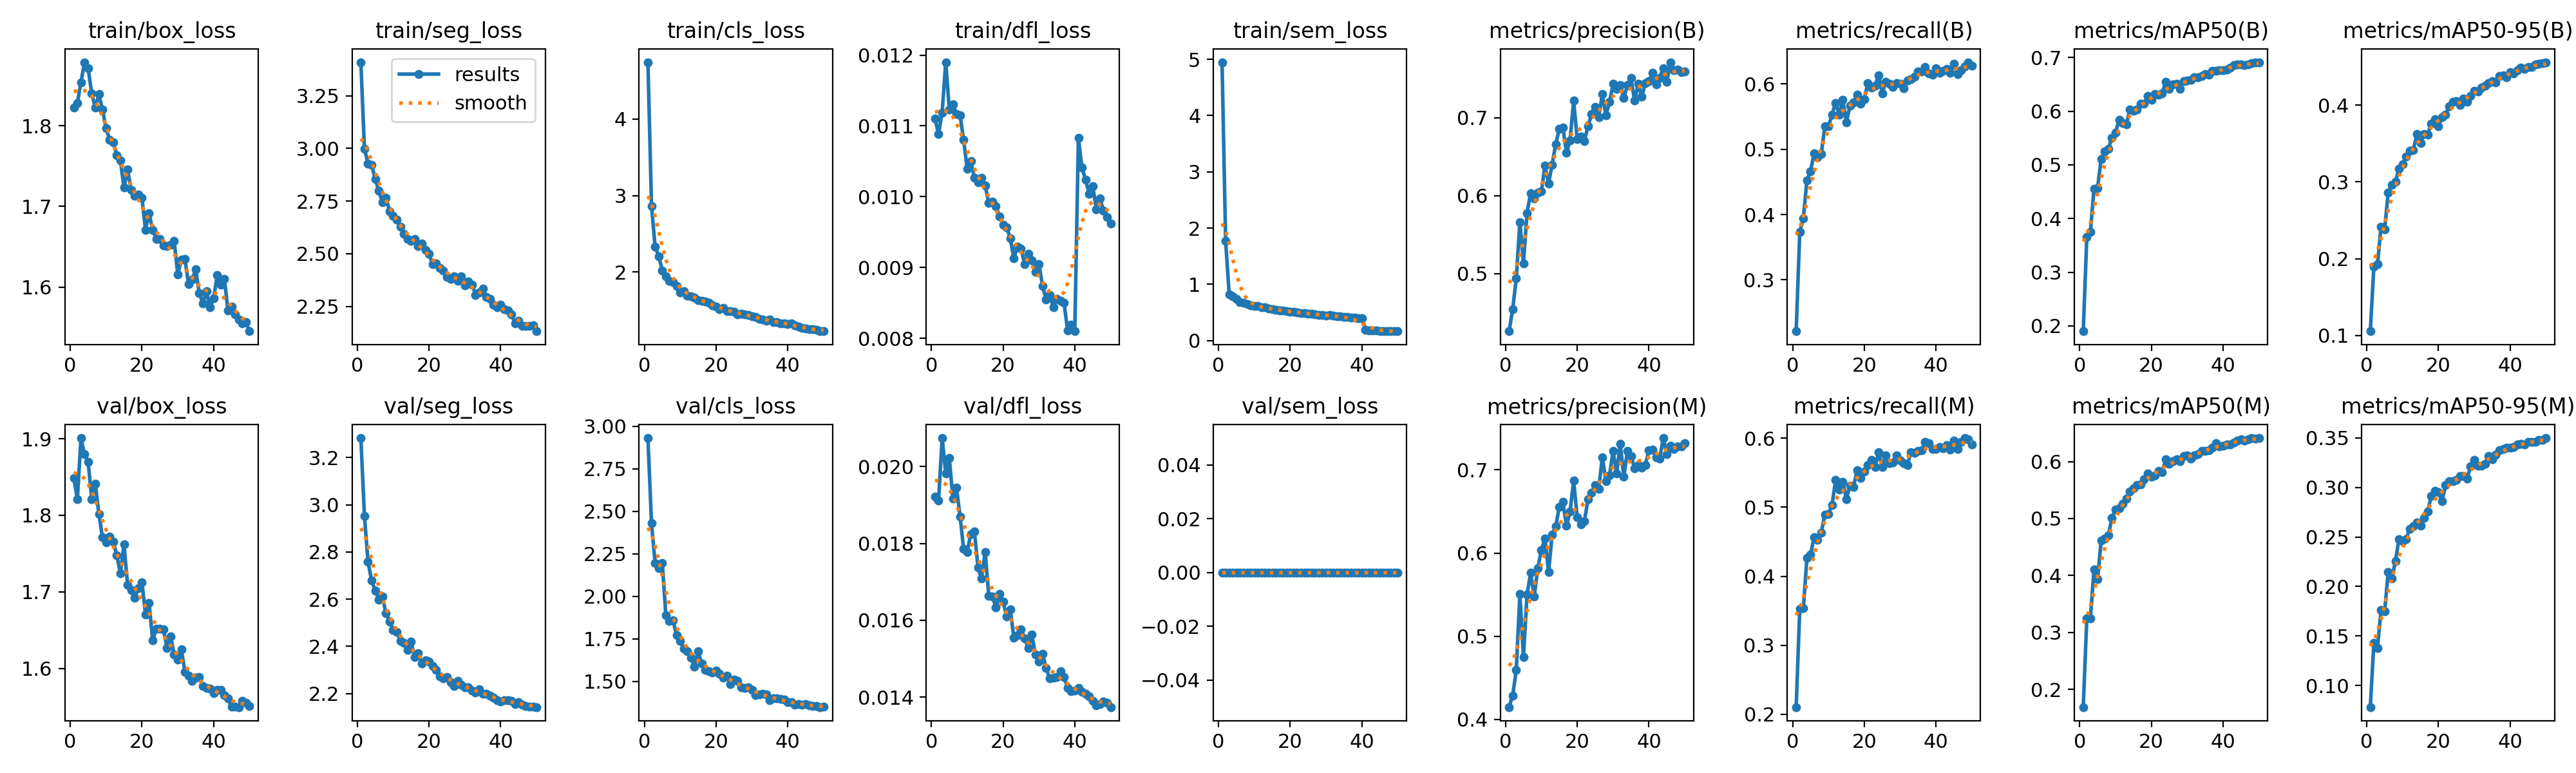

In [4]:
from IPython.display import Image

# Display the master results image (shows loss curves and mAP over the 50 epochs)
Image(filename='/kaggle/working/runs/segment/structure_model/iteration_1/results.png', width=1000)

In [5]:
from IPython.display import FileLink

# This generates a clickable link in your notebook to download your custom weights
print("Click the link below to download your trained model weights:")
FileLink('/kaggle/working/runs/segment/structure_model/iteration_1/weights/best.pt')

Click the link below to download your trained model weights:


/kaggle/working/runs/segment/structure_model/iteration_1/weights/best.pt

In [6]:
shutil.make_archive('my_backup_model', 'zip', 'structure_model')

print("Zipping complete!")

NameError: name 'shutil' is not defined